In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv("/home/jupyter/project/course work/1/try to predict one line/a.csv")

In [77]:
df.head()

,AC,AF,AR,AS,AST,AY,AwayTeam,Date,FTAG,FTHG,FTR,HC,HF,HR,HS,HST,HTAG,HTHG,HTR,HY,HomeTeam,Referee,Season,WHA,WHD,WHH
0,6.0,12.0,0.0,8.0,4.0,2.0,Man City,19/08/00,0.0,4.0,H,6.0,13.0,0.0,17.0,14.0,0.0,2.0,H,1.0,Charlton,Rob Harris,2000-2001,3.10,3.2,2.10
1,7.0,14.0,0.0,12.0,5.0,2.0,West Ham,19/08/00,2.0,4.0,H,7.0,19.0,0.0,17.0,10.0,0.0,1.0,H,1.0,Chelsea,Graham Barber,2000-2001,6.50,3.6,1.44
2,4.0,21.0,0.0,16.0,9.0,3.0,Middlesbrough,19/08/00,3.0,1.0,A,8.0,15.0,1.0,6.0,3.0,1.0,1.0,D,5.0,Coventry,Barry Knight,2000-2001,2.62,3.2,2.30
3,8.0,13.0,0.0,13.0,6.0,1.0,Southampton,19/08/00,2.0,2.0,D,5.0,11.0,0.0,6.0,4.0,2.0,1.0,A,1.0,Derby,Andy D'Urso,2000-2001,3.20,3.2,2.00
4,4.0,20.0,0.0,12.0,6.0,3.0,Everton,19/08/00,0.0,2.0,H,6.0,21.0,0.0,17.0,8.0,0.0,2.0,H,1.0,Leeds,Dermot Gallagher,2000-2001,4.50,3.5,1.61


In [78]:
def sort_by_date(df, column=['Season', 'Date'], ascending=True, reset_index=True):
    df_sorted = df.copy()

    def parse_date_with_formats(date_str):
        date_str = str(date_str).strip().split("/")
        assert len(date_str) == 3

        # year
        result = ""
        if len(date_str[2]) == 2:
          result += "20" + date_str[2]
        elif len(date_str[2]) == 4:
          result += date_str[2]
        else:
          raise Exception

        #month
        result += "/" + date_str[1]

        # day
        result += "/" + date_str[0]
        return result

    df_sorted["Date"] = df_sorted["Date"].apply(parse_date_with_formats)

    df_sorted = df_sorted.sort_values(by=column, ascending=ascending)

    if reset_index:
        df_sorted = df_sorted.reset_index(drop=True)

    return df_sorted

In [79]:
df_sort_date = sort_by_date(df)

In [80]:
df_sort_date.head()

,AC,AF,AR,AS,AST,AY,AwayTeam,Date,FTAG,FTHG,FTR,HC,HF,HR,HS,HST,HTAG,HTHG,HTR,HY,HomeTeam,Referee,Season,WHA,WHD,WHH
0,6.0,12.0,0.0,8.0,4.0,2.0,Man City,2000/08/19,0.0,4.0,H,6.0,13.0,0.0,17.0,14.0,0.0,2.0,H,1.0,Charlton,Rob Harris,2000-2001,3.10,3.2,2.10
1,7.0,14.0,0.0,12.0,5.0,2.0,West Ham,2000/08/19,2.0,4.0,H,7.0,19.0,0.0,17.0,10.0,0.0,1.0,H,1.0,Chelsea,Graham Barber,2000-2001,6.50,3.6,1.44
2,4.0,21.0,0.0,16.0,9.0,3.0,Middlesbrough,2000/08/19,3.0,1.0,A,8.0,15.0,1.0,6.0,3.0,1.0,1.0,D,5.0,Coventry,Barry Knight,2000-2001,2.62,3.2,2.30
3,8.0,13.0,0.0,13.0,6.0,1.0,Southampton,2000/08/19,2.0,2.0,D,5.0,11.0,0.0,6.0,4.0,2.0,1.0,A,1.0,Derby,Andy D'Urso,2000-2001,3.20,3.2,2.00
4,4.0,20.0,0.0,12.0,6.0,3.0,Everton,2000/08/19,0.0,2.0,H,6.0,21.0,0.0,17.0,8.0,0.0,2.0,H,1.0,Leeds,Dermot Gallagher,2000-2001,4.50,3.5,1.61


In [81]:
df.shape

(9410, 26)

In [82]:
df_sort_date.columns

Index(['AC', 'AF', 'AR', 'AS', 'AST', 'AY', 'AwayTeam', 'Date', 'FTAG', 'FTHG',
       'FTR', 'HC', 'HF', 'HR', 'HS', 'HST', 'HTAG', 'HTHG', 'HTR', 'HY',
       'HomeTeam', 'Referee', 'Season', 'WHA', 'WHD', 'WHH'],
      dtype='object')

In [83]:
df_sort_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9410 entries, 0 to 9409
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AC        9410 non-null   float64
 1   AF        9410 non-null   float64
 2   AR        9410 non-null   float64
 3   AS        9410 non-null   float64
 4   AST       9410 non-null   float64
 5   AY        9410 non-null   float64
 6   AwayTeam  9410 non-null   object 
 7   Date      9410 non-null   object 
 8   FTAG      9410 non-null   float64
 9   FTHG      9410 non-null   float64
 10  FTR       9410 non-null   object 
 11  HC        9410 non-null   float64
 12  HF        9410 non-null   float64
 13  HR        9410 non-null   float64
 14  HS        9410 non-null   float64
 15  HST       9410 non-null   float64
 16  HTAG      9410 non-null   float64
 17  HTHG      9410 non-null   float64
 18  HTR       9410 non-null   object 
 19  HY        9410 non-null   float64
 20  HomeTeam  9410 non-null   obje

Основная информация о матче:

* Date - Дата матча
* Season - Сезон
* HomeTeam - Домашняя команда
* AwayTeam - Гостевая команда
* Referee - Судья

Результаты матча (Full Time):

* FTHG - Full Time Home Goals (голы хозяев в основное время)
* FTAG - Full Time Away Goals (голы гостей в основное время)
* FTR - Full Time Result (результат: H=победа хозяев, A=победа гостей, D=ничья)

Результаты тайма (Half Time):

* HTHG - Half Time Home Goals (голы хозяев в первом тайме)
* HTAG - Half Time Away Goals (голы гостей в первом тайме)
* HTR - Half Time Result (результат первого тайма)

Статистика хозяев (Home):

* HS - Home Shots (удары)
* HST - Home Shots on Target (удары в створ)
* HF - Home Fouls (фолы)
* HC - Home Corners (угловые)
* HY - Home Yellow cards (желтые карточки)
* HR - Home Red cards (красные карточки)

Статистика гостей (Away):

* AS - Away Shots (удары)
* AST - Away Shots on Target (удары в створ)
* AF - Away Fouls (фолы)
* AC - Away Corners (угловые)
* AY - Away Yellow cards (желтые карточки)
* AR - Away Red cards (красные карточки)

Букмекерские коэффициенты (William Hill):

* WHH - William Hill Home win odds (коэффициент на победу хозяев)
* WHD - William Hill Draw odds (коэффициент на ничью)
* WHA - William Hill Away win odds (коэффициент на победу гостей)

буду для каждой команды писать

0 - команда проиграла

1 - команда сыграла в ничью в этом матче

2 - команда победила

In [84]:
new_data = []

for index, row in df_sort_date.iterrows():
    # all
    date = row["Date"]
    season = row["Season"]
    referee = row["Referee"]
    
    # home
    home_team = row['HomeTeam']
    enemy_team = row["AwayTeam"]
    
    ftg = row["FTHG"]
    enemy_ftg = row["FTAG"]
    
    htg = row["HTHG"]
    enemy_htg = row["HTAG"]
    
    s = row["HS"]
    st = row["HST"]
    f = row["HF"]
    c = row["HC"]
    y = row["HY"]
    r = row["HR"]
    
    enemy_s = row["AS"]
    enemy_st = row["AST"]
    enemy_f = row["AF"]
    enemy_c = row["AC"]
    enemy_y = row["AY"]
    enemy_r = row["AR"]
    
    if row["HTR"] == "H":
        ht_w = 1
        ht_d = 0
        ht_l = 0
    elif row["HTR"] == "A":
        ht_w = 0
        ht_d = 0
        ht_l = 1
    elif row["HTR"] == "D":
        ht_w = 0
        ht_d = 1
        ht_l = 0
    
    if row["FTR"] == "H":
        match_result = 2
    elif row["FTR"] == "A":
        match_result = 0
    elif row["FTR"] == "D":
        match_result = 1
        
    new_data.append(
        {
            "date": date, 
             "season": season,
             "referee": referee,
             "team": home_team,
            "enemy_team": enemy_team,
             "match_result": match_result,
             "ftg": ftg,
            "enemy_ftg": enemy_ftg,
            "s": s,
            "st": st,
            "f": f,
            "c": c,
            "y": y,
            "r": r,
            "enemy_s": enemy_s,
            "enemy_st": enemy_st,
            "enemy_f": enemy_f,
            "enemy_c": enemy_c,
            "enemy_y": enemy_y,
            "enemy_r": enemy_r,
            "ht_w": ht_w,
            "ht_d": ht_d,
            "ht_l": ht_l
        })
    
    # away
    away_team = row['AwayTeam']
    enemy_team = row["HomeTeam"]
    
    ftg = row["FTAG"]
    enemy_ftg = row["FTHG"]
    
    htg = row["HTAG"]
    enemy_htg = row["HTHG"]
    
    s = row["AS"]
    st = row["AST"]
    f = row["AF"]
    c = row["AC"]
    y = row["AY"]
    r = row["AR"]
    
    enemy_s = row["HS"]
    enemy_st = row["HST"]
    enemy_f = row["HF"]
    enemy_c = row["HC"]
    enemy_y = row["HY"]
    enemy_r = row["HR"]
    
    if row["HTR"] == "H":
        ht_w = 0
        ht_d = 0
        ht_l = 1
    elif row["HTR"] == "A":
        ht_w = 1
        ht_d = 0
        ht_l = 0
    elif row["HTR"] == "D":
        ht_w = 0
        ht_d = 1
        ht_l = 0
    
    if row["FTR"] == "H":
        match_result = 0
    elif row["FTR"] == "A":
        match_result = 2
    elif row["FTR"] == "D":
        match_result = 1
        
    new_data.append(
        {
            "date": date, 
             "season": season,
             "referee": referee,
             "team": away_team,
            "enemy_team": enemy_team,
             "match_result": match_result,
             "ftg": ftg,
            "enemy_ftg": enemy_ftg,
            "s": s,
            "st": st,
            "f": f,
            "c": c,
            "y": y,
            "r": r,
            "enemy_s": enemy_s,
            "enemy_st": enemy_st,
            "enemy_f": enemy_f,
            "enemy_c": enemy_c,
            "enemy_y": enemy_y,
            "enemy_r": enemy_r,
            "ht_w": ht_w,
            "ht_d": ht_d,
            "ht_l": ht_l
        })
    

In [85]:
df_one_line = pd.DataFrame(new_data)

In [86]:
df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l
0,2000/08/19,2000-2001,Rob Harris,Charlton,Man City,2,4.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,8.0,4.0,12.0,6.0,2.0,0.0,1,0,0
1,2000/08/19,2000-2001,Rob Harris,Man City,Charlton,0,0.0,4.0,8.0,4.0,12.0,6.0,2.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,0,0,1
2,2000/08/19,2000-2001,Graham Barber,Chelsea,West Ham,2,4.0,2.0,17.0,10.0,19.0,7.0,1.0,0.0,12.0,5.0,14.0,7.0,2.0,0.0,1,0,0
3,2000/08/19,2000-2001,Graham Barber,West Ham,Chelsea,0,2.0,4.0,12.0,5.0,14.0,7.0,2.0,0.0,17.0,10.0,19.0,7.0,1.0,0.0,0,0,1
4,2000/08/19,2000-2001,Barry Knight,Coventry,Middlesbrough,0,1.0,3.0,6.0,3.0,15.0,8.0,5.0,1.0,16.0,9.0,21.0,4.0,3.0,0.0,0,1,0


In [87]:
df_one_line['date'] = pd.to_datetime(df_one_line['date'])
df_one_line

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l
0,2000-08-19,2000-2001,Rob Harris,Charlton,Man City,2,4.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,8.0,4.0,12.0,6.0,2.0,0.0,1,0,0
1,2000-08-19,2000-2001,Rob Harris,Man City,Charlton,0,0.0,4.0,8.0,4.0,12.0,6.0,2.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,0,0,1
2,2000-08-19,2000-2001,Graham Barber,Chelsea,West Ham,2,4.0,2.0,17.0,10.0,19.0,7.0,1.0,0.0,12.0,5.0,14.0,7.0,2.0,0.0,1,0,0
3,2000-08-19,2000-2001,Graham Barber,West Ham,Chelsea,0,2.0,4.0,12.0,5.0,14.0,7.0,2.0,0.0,17.0,10.0,19.0,7.0,1.0,0.0,0,0,1
4,2000-08-19,2000-2001,Barry Knight,Coventry,Middlesbrough,0,1.0,3.0,6.0,3.0,15.0,8.0,5.0,1.0,16.0,9.0,21.0,4.0,3.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18815,2025-05-25,2024-2025,D Bond,Arsenal,Southampton,2,2.0,1.0,23.0,8.0,8.0,8.0,0.0,0.0,7.0,2.0,7.0,5.0,0.0,0.0,1,0,0
18816,2025-05-25,2024-2025,R Jones,Tottenham,Brighton,0,1.0,4.0,4.0,2.0,13.0,2.0,3.0,0.0,23.0,8.0,8.0,11.0,1.0,0.0,1,0,0
18817,2025-05-25,2024-2025,R Jones,Brighton,Tottenham,2,4.0,1.0,23.0,8.0,8.0,11.0,1.0,0.0,4.0,2.0,13.0,2.0,3.0,0.0,0,0,1
18818,2025-05-25,2024-2025,C Pawson,Wolves,Brentford,1,1.0,1.0,18.0,6.0,7.0,8.0,2.0,0.0,13.0,7.0,9.0,3.0,1.0,0.0,0,0,1


<Axes: >

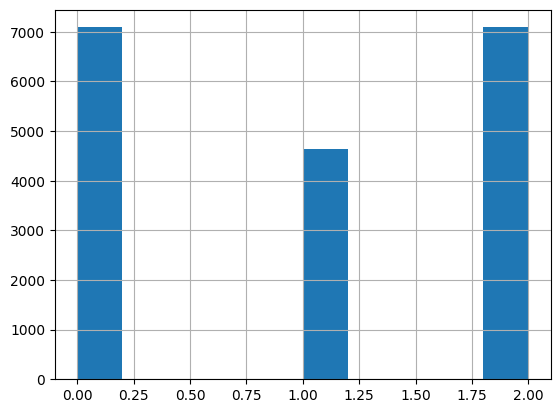

In [88]:
df_one_line["match_result"].hist()

In [89]:
teams = df_one_line["team"].value_counts()[:10].index
teams

Index(['Man United', 'Everton', 'Tottenham', 'Liverpool', 'Arsenal', 'Chelsea',
       'Man City', 'Newcastle', 'West Ham', 'Aston Villa'],
      dtype='object')

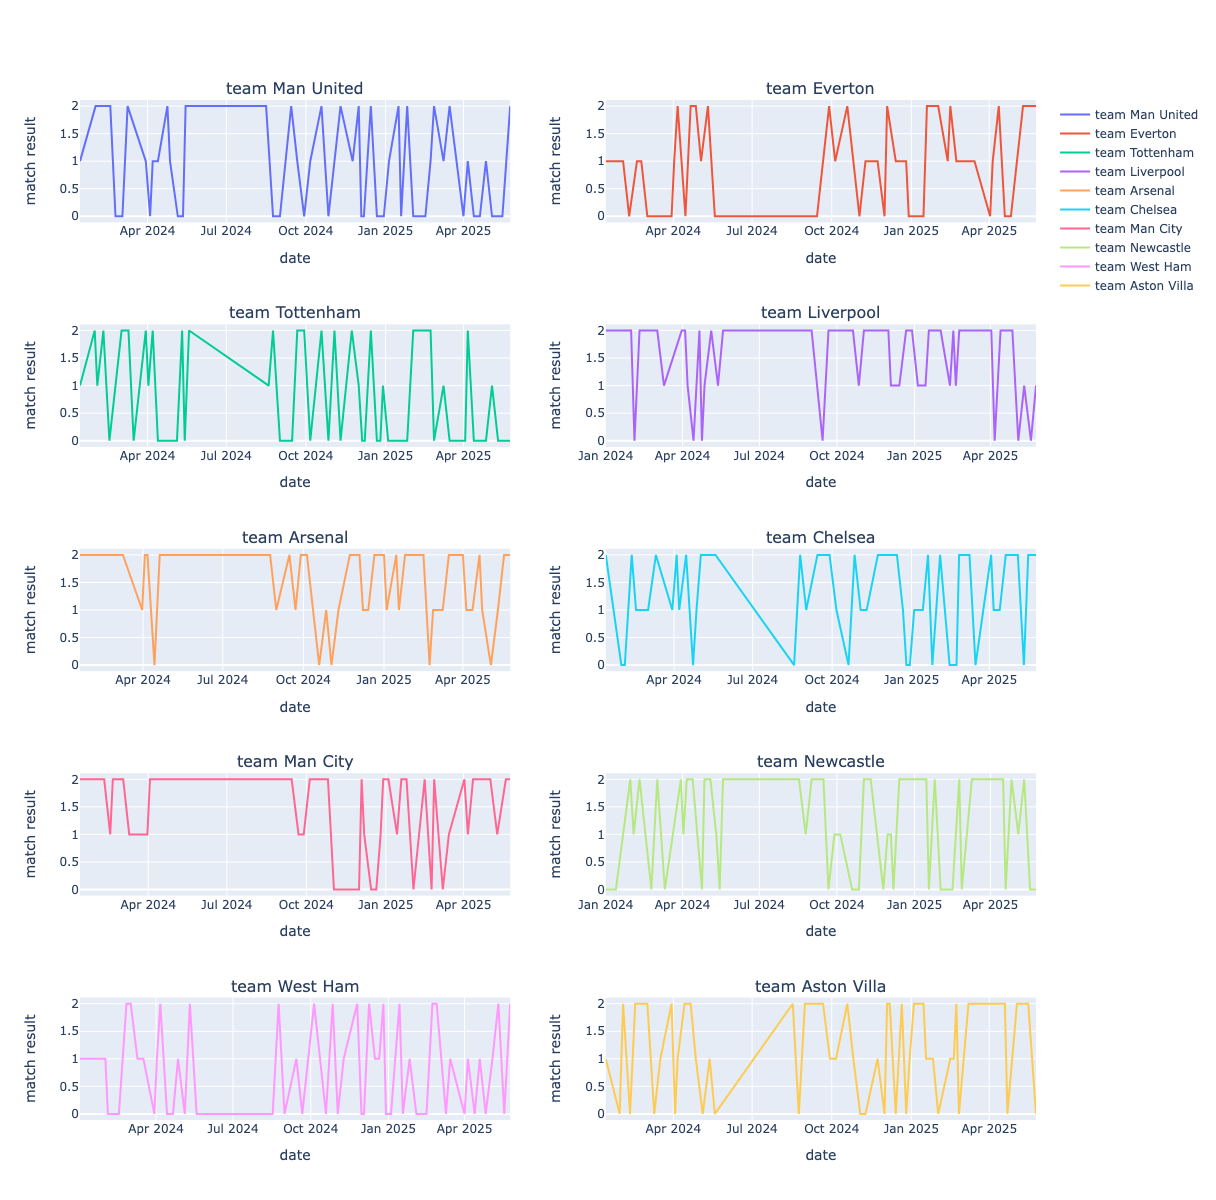

In [35]:
fig = make_subplots(rows=5, cols=2, subplot_titles=[f'team {team}' for team in teams])

for idx, id in enumerate(teams):
    fig.add_trace(
        go.Scatter(
            x=df_one_line[(df_one_line['team'] == id) & (df_one_line['date'].dt.year >= 2024)]['date'],
            y=df_one_line[(df_one_line['team'] == id) & (df_one_line['date'].dt.year >= 2024)]['match_result'],
            mode='lines',
            name=f'team {id}'
        ),
        row=(idx // 2 + 1), col=(idx % 2 + 1)
    )

fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="match result")

fig.update_layout(
    height=1200,
    showlegend=True
)

fig.show()

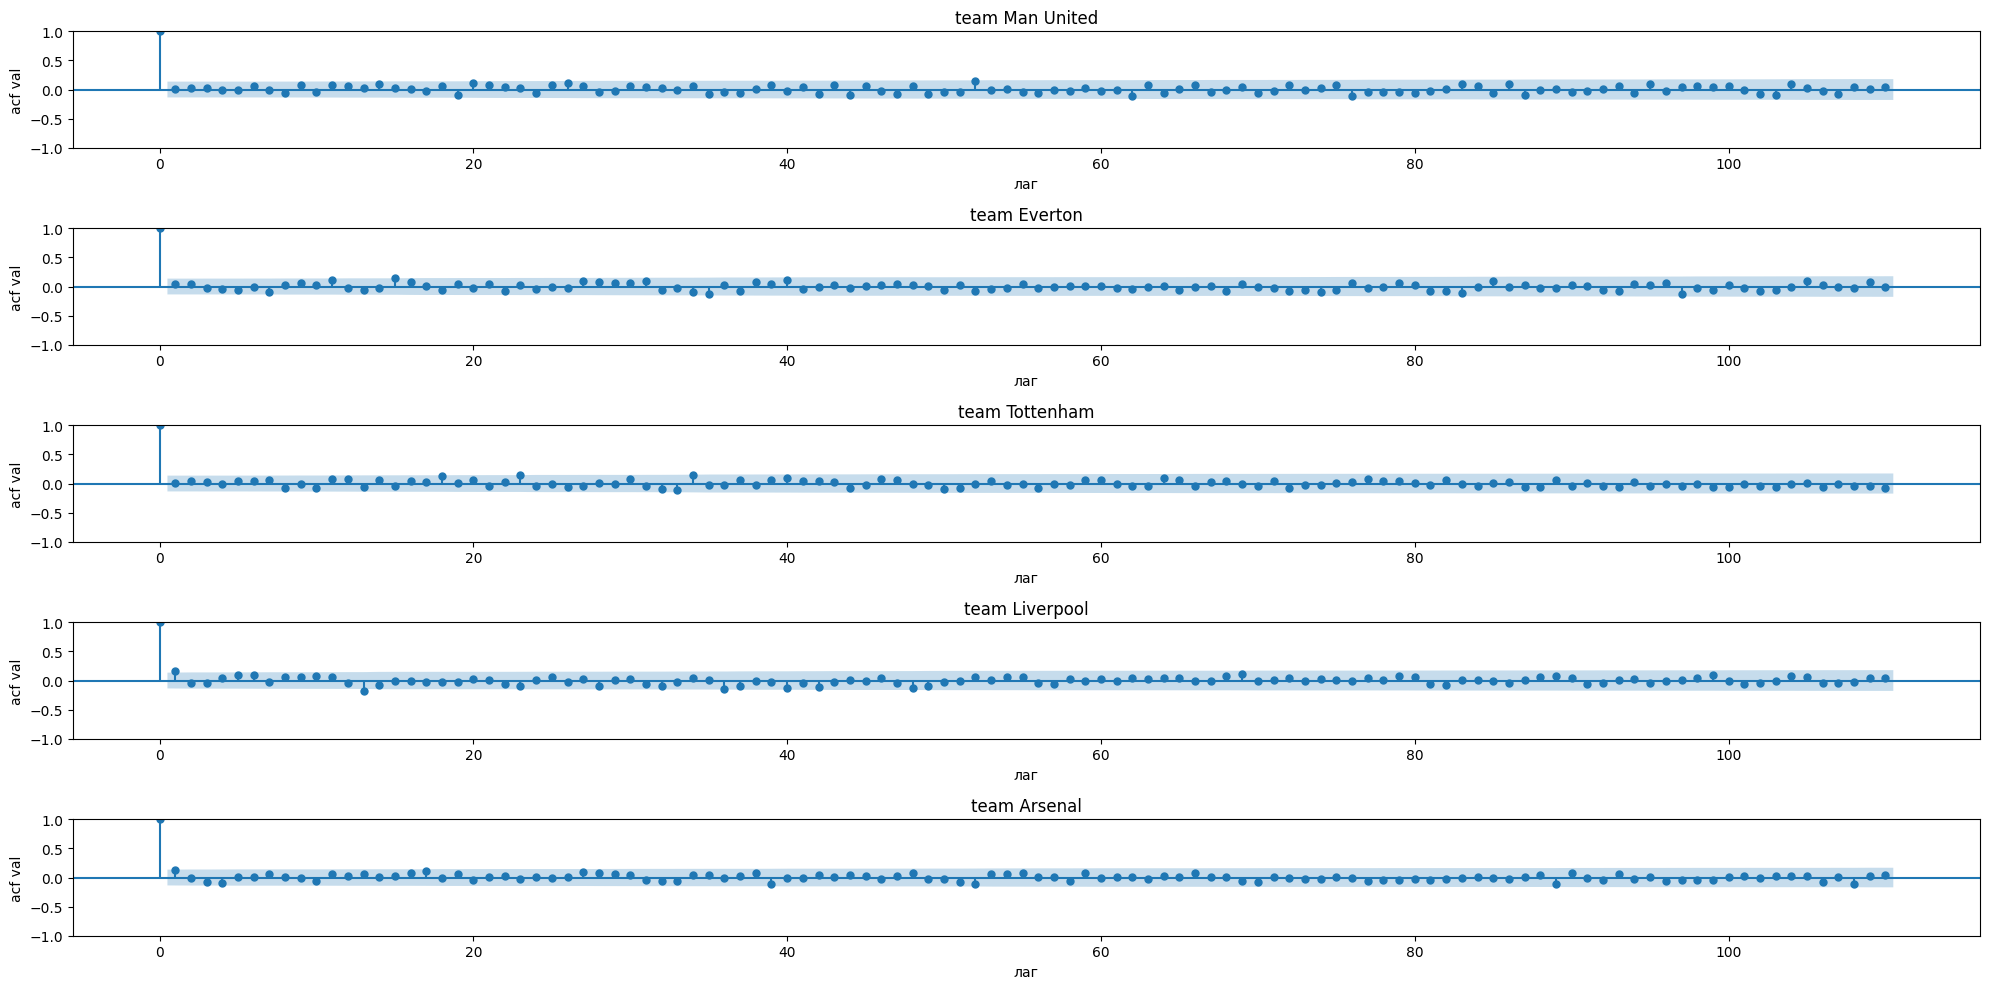

In [46]:
fig, axes = plt.subplots(5, 1, figsize=(20, 10))

for idx, id in enumerate(teams[:5]):
    curr_val = df_one_line[(df_one_line['team'] == id) & (df_one_line['date'].dt.year >= 2020)]['match_result'].copy()

    plot_acf(curr_val, lags=110, ax=axes[idx])
    axes[idx].set_title(f'team {id}')
    axes[idx].set_xlabel('лаг')
    axes[idx].set_ylabel('acf val')

plt.tight_layout()
plt.show()

In [90]:
df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l
0,2000-08-19,2000-2001,Rob Harris,Charlton,Man City,2,4.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,8.0,4.0,12.0,6.0,2.0,0.0,1,0,0
1,2000-08-19,2000-2001,Rob Harris,Man City,Charlton,0,0.0,4.0,8.0,4.0,12.0,6.0,2.0,0.0,17.0,14.0,13.0,6.0,1.0,0.0,0,0,1
2,2000-08-19,2000-2001,Graham Barber,Chelsea,West Ham,2,4.0,2.0,17.0,10.0,19.0,7.0,1.0,0.0,12.0,5.0,14.0,7.0,2.0,0.0,1,0,0
3,2000-08-19,2000-2001,Graham Barber,West Ham,Chelsea,0,2.0,4.0,12.0,5.0,14.0,7.0,2.0,0.0,17.0,10.0,19.0,7.0,1.0,0.0,0,0,1
4,2000-08-19,2000-2001,Barry Knight,Coventry,Middlesbrough,0,1.0,3.0,6.0,3.0,15.0,8.0,5.0,1.0,16.0,9.0,21.0,4.0,3.0,0.0,0,1,0


In [91]:
df_one_line = df_one_line.sort_values(by=["team", "date"]).copy()

# Разность по ряду — как отдельный признак (НЕ новый таргет)
# Обязательно нужно сделать shift, чтобы не было "заглядывания в будущее"
df_one_line["match_result_diff1"] = df_one_line.groupby("team")["match_result"].shift(1).diff()

df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l,match_result_diff1
15,2000-08-19,2000-2001,Steve Dunn,Arsenal,Sunderland,0,0.0,1.0,14.0,7.0,21.0,9.0,1.0,1.0,8.0,2.0,10.0,2.0,3.0,0.0,0,1,0,NaN
20,2000-08-21,2000-2001,Graham Poll,Arsenal,Liverpool,2,2.0,0.0,17.0,12.0,25.0,10.0,2.0,1.0,7.0,4.0,20.0,11.0,4.0,2.0,1,0,0,NaN
38,2000-08-26,2000-2001,Steve Lodge,Arsenal,Charlton,2,5.0,3.0,18.0,9.0,12.0,8.0,0.0,0.0,7.0,4.0,15.0,3.0,1.0,0.0,0,0,1,2.0
69,2000-09-06,2000-2001,Mike Riley,Arsenal,Chelsea,1,2.0,2.0,13.0,5.0,22.0,6.0,1.0,0.0,12.0,5.0,16.0,7.0,3.0,0.0,0,0,1,0.0
79,2000-09-09,2000-2001,Alan Wiley,Arsenal,Bradford,1,1.0,1.0,18.0,11.0,13.0,10.0,2.0,0.0,9.0,5.0,17.0,4.0,0.0,0.0,0,0,1,-1.0


In [92]:
from typing import Dict, List, Optional, Tuple

def add_time_features(df: pd.DataFrame, time_col: str = "date") -> pd.DataFrame:
    """
    Календарные признаки для временной колонки.
    """
    out = df.copy()
    dt = pd.to_datetime(out[time_col])

    out["year"] = dt.dt.year
    out["month"] = dt.dt.month
    out["day"] = dt.dt.day
    out["dow"] = dt.dt.dayofweek
    out["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    out["is_weekend"] = (out["dow"] >= 5).astype(int)

    return out


def add_lag_features(
    df: pd.DataFrame,
    group_col: str,
    target_cols: List[str],
    lags: List[int],
    time_col: str = "date",
) -> pd.DataFrame:
    """
    Лаги целевой переменной. Ликов нет, если потом мы не нарушаем временной порядок при обучении модели.
    """
    out = df.copy().sort_values(by=[group_col, time_col])
    for target_col in target_cols:
        for lag in lags:
            out[f"{target_col}_lag_{lag}"] = out.groupby(group_col)[target_col].shift(lag)
    return out


def add_rolling_features(
    df: pd.DataFrame,
    group_col: str,
    target_cols: List[str],
    windows: List[int],
    time_col: str = "date",
) -> pd.DataFrame:
    """
    Оконные средние и std по каждому ряду.
    """
    out = df.copy().sort_values(by=[group_col, time_col])
    for target_col in target_cols:
        for window in windows:
            # Обязательно нужно сделать shift, чтобы не было "заглядывания в будущее"
            roll = out.groupby(group_col)[target_col].shift(1).rolling(window=window, min_periods=1)
            if not roll.mean().isna().all():
                out[f"{target_col}_roll_mean_{window}"] = roll.mean()
            if not roll.std().isna().all():
                out[f"{target_col}_roll_std_{window}"] = roll.std()
           
    return out

In [93]:
df_one_line = add_time_features(df_one_line)
df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l,match_result_diff1,year,month,day,dow,weekofyear,is_weekend
15,2000-08-19,2000-2001,Steve Dunn,Arsenal,Sunderland,0,0.0,1.0,14.0,7.0,21.0,9.0,1.0,1.0,8.0,2.0,10.0,2.0,3.0,0.0,0,1,0,NaN,2000,8,19,5,33,1
20,2000-08-21,2000-2001,Graham Poll,Arsenal,Liverpool,2,2.0,0.0,17.0,12.0,25.0,10.0,2.0,1.0,7.0,4.0,20.0,11.0,4.0,2.0,1,0,0,NaN,2000,8,21,0,34,0
38,2000-08-26,2000-2001,Steve Lodge,Arsenal,Charlton,2,5.0,3.0,18.0,9.0,12.0,8.0,0.0,0.0,7.0,4.0,15.0,3.0,1.0,0.0,0,0,1,2.0,2000,8,26,5,34,1
69,2000-09-06,2000-2001,Mike Riley,Arsenal,Chelsea,1,2.0,2.0,13.0,5.0,22.0,6.0,1.0,0.0,12.0,5.0,16.0,7.0,3.0,0.0,0,0,1,0.0,2000,9,6,2,36,0
79,2000-09-09,2000-2001,Alan Wiley,Arsenal,Bradford,1,1.0,1.0,18.0,11.0,13.0,10.0,2.0,0.0,9.0,5.0,17.0,4.0,0.0,0.0,0,0,1,-1.0,2000,9,9,5,36,1


In [94]:
unknown_cols = [
    "match_result", 
    "ftg", 
    "enemy_ftg", 
    "s",
    "st",
    "f",
    "c",
    "y",
    "r",
    "enemy_s",
    "enemy_st",
    "enemy_f",
    "enemy_c",
    "enemy_y",
    "enemy_r",
    "ht_w",
    "ht_d",
    "ht_l",
    ]

In [95]:
df_one_line = add_lag_features(df_one_line, group_col="team", target_cols=unknown_cols, lags=[1, 2, 3, 4, 5])
df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l,match_result_diff1,year,month,day,dow,weekofyear,is_weekend,match_result_lag_1,match_result_lag_2,match_result_lag_3,match_result_lag_4,match_result_lag_5,ftg_lag_1,ftg_lag_2,ftg_lag_3,ftg_lag_4,ftg_lag_5,...,enemy_st_lag_1,enemy_st_lag_2,enemy_st_lag_3,enemy_st_lag_4,enemy_st_lag_5,enemy_f_lag_1,enemy_f_lag_2,enemy_f_lag_3,enemy_f_lag_4,enemy_f_lag_5,enemy_c_lag_1,enemy_c_lag_2,enemy_c_lag_3,enemy_c_lag_4,enemy_c_lag_5,enemy_y_lag_1,enemy_y_lag_2,enemy_y_lag_3,enemy_y_lag_4,enemy_y_lag_5,enemy_r_lag_1,enemy_r_lag_2,enemy_r_lag_3,enemy_r_lag_4,enemy_r_lag_5,ht_w_lag_1,ht_w_lag_2,ht_w_lag_3,ht_w_lag_4,ht_w_lag_5,ht_d_lag_1,ht_d_lag_2,ht_d_lag_3,ht_d_lag_4,ht_d_lag_5,ht_l_lag_1,ht_l_lag_2,ht_l_lag_3,ht_l_lag_4,ht_l_lag_5
15,2000-08-19,2000-2001,Steve Dunn,Arsenal,Sunderland,0,0.0,1.0,14.0,7.0,21.0,9.0,1.0,1.0,8.0,2.0,10.0,2.0,3.0,0.0,0,1,0,NaN,2000,8,19,5,33,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2000-08-21,2000-2001,Graham Poll,Arsenal,Liverpool,2,2.0,0.0,17.0,12.0,25.0,10.0,2.0,1.0,7.0,4.0,20.0,11.0,4.0,2.0,1,0,0,NaN,2000,8,21,0,34,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
38,2000-08-26,2000-2001,Steve Lodge,Arsenal,Charlton,2,5.0,3.0,18.0,9.0,12.0,8.0,0.0,0.0,7.0,4.0,15.0,3.0,1.0,0.0,0,0,1,2.0,2000,8,26,5,34,1,2.0,0.0,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,...,4.0,2.0,NaN,NaN,NaN,20.0,10.0,NaN,NaN,NaN,11.0,2.0,NaN,NaN,NaN,4.0,3.0,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
69,2000-09-06,2000-2001,Mike Riley,Arsenal,Chelsea,1,2.0,2.0,13.0,5.0,22.0,6.0,1.0,0.0,12.0,5.0,16.0,7.0,3.0,0.0,0,0,1,0.0,2000,9,6,2,36,0,2.0,2.0,0.0,NaN,NaN,5.0,2.0,0.0,NaN,NaN,...,4.0,4.0,2.0,NaN,NaN,15.0,20.0,10.0,NaN,NaN,3.0,11.0,2.0,NaN,NaN,1.0,4.0,3.0,NaN,NaN,0.0,2.0,0.0,NaN,NaN,0.0,1.0,0.0,NaN,NaN,0.0,0.0,1.0,NaN,NaN,1.0,0.0,0.0,NaN,NaN
79,2000-09-09,2000-2001,Alan Wiley,Arsenal,Bradford,1,1.0,1.0,18.0,11.0,13.0,10.0,2.0,0.0,9.0,5.0,17.0,4.0,0.0,0.0,0,0,1,-1.0,2000,9,9,5,36,1,1.0,2.0,2.0,0.0,NaN,2.0,5.0,2.0,0.0,NaN,...,5.0,4.0,4.0,2.0,NaN,16.0,15.0,20.0,10.0,NaN,7.0,3.0,11.0,2.0,NaN,3.0,1.0,4.0,3.0,NaN,0.0,0.0,2.0,0.0,NaN,0.0,0.0,1.0,0.0,NaN,0.0,0.0,0.0,1.0,NaN,1.0,1.0,0.0,0.0,NaN


In [96]:
df_one_line = add_rolling_features(df_one_line, group_col="team", target_cols=unknown_cols, windows=[1, 2, 3, 4, 5, 7, 10, 15, 20])
df_one_line.head()

/tmp/ipykernel_3709/3239163503.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{target_col}_roll_mean_{window}"] = roll.mean()
/tmp/ipykernel_3709/3239163503.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{target_col}_roll_std_{window}"] = roll.std()
/tmp/ipykernel_3709/3239163503.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To ge

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l,match_result_diff1,year,month,day,dow,weekofyear,is_weekend,match_result_lag_1,match_result_lag_2,match_result_lag_3,match_result_lag_4,match_result_lag_5,ftg_lag_1,ftg_lag_2,ftg_lag_3,ftg_lag_4,ftg_lag_5,...,ht_w_roll_mean_10,ht_w_roll_std_10,ht_w_roll_mean_15,ht_w_roll_std_15,ht_w_roll_mean_20,ht_w_roll_std_20,ht_d_roll_mean_1,ht_d_roll_mean_2,ht_d_roll_std_2,ht_d_roll_mean_3,ht_d_roll_std_3,ht_d_roll_mean_4,ht_d_roll_std_4,ht_d_roll_mean_5,ht_d_roll_std_5,ht_d_roll_mean_7,ht_d_roll_std_7,ht_d_roll_mean_10,ht_d_roll_std_10,ht_d_roll_mean_15,ht_d_roll_std_15,ht_d_roll_mean_20,ht_d_roll_std_20,ht_l_roll_mean_1,ht_l_roll_mean_2,ht_l_roll_std_2,ht_l_roll_mean_3,ht_l_roll_std_3,ht_l_roll_mean_4,ht_l_roll_std_4,ht_l_roll_mean_5,ht_l_roll_std_5,ht_l_roll_mean_7,ht_l_roll_std_7,ht_l_roll_mean_10,ht_l_roll_std_10,ht_l_roll_mean_15,ht_l_roll_std_15,ht_l_roll_mean_20,ht_l_roll_std_20
15,2000-08-19,2000-2001,Steve Dunn,Arsenal,Sunderland,0,0.0,1.0,14.0,7.0,21.0,9.0,1.0,1.0,8.0,2.0,10.0,2.0,3.0,0.0,0,1,0,NaN,2000,8,19,5,33,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2000-08-21,2000-2001,Graham Poll,Arsenal,Liverpool,2,2.0,0.0,17.0,12.0,25.0,10.0,2.0,1.0,7.0,4.0,20.0,11.0,4.0,2.0,1,0,0,NaN,2000,8,21,0,34,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,0.000000,NaN,0.000000,NaN,0.000000,NaN,1.0,1.0,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.0,0.0,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
38,2000-08-26,2000-2001,Steve Lodge,Arsenal,Charlton,2,5.0,3.0,18.0,9.0,12.0,8.0,0.0,0.0,7.0,4.0,15.0,3.0,1.0,0.0,0,0,1,2.0,2000,8,26,5,34,1,2.0,0.0,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,...,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.0,0.5,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
69,2000-09-06,2000-2001,Mike Riley,Arsenal,Chelsea,1,2.0,2.0,13.0,5.0,22.0,6.0,1.0,0.0,12.0,5.0,16.0,7.0,3.0,0.0,0,0,1,0.0,2000,9,6,2,36,0,2.0,2.0,0.0,NaN,NaN,5.0,2.0,0.0,NaN,NaN,...,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.0,0.0,0.000000,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,1.0,0.5,0.707107,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735
79,2000-09-09,2000-2001,Alan Wiley,Arsenal,Bradford,1,1.0,1.0,18.0,11.0,13.0,10.0,2.0,0.0,9.0,5.0,17.0,4.0,0.0,0.0,0,0,1,-1.0,2000,9,9,5,36,1,1.0,2.0,2.0,0.0,NaN,2.0,5.0,2.0,0.0,NaN,...,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.0,0.0,0.000000,0.000000,0.000000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,1.0,1.0,0.000000,0.666667,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735


In [97]:
df_one_line.head()

,date,season,referee,team,enemy_team,match_result,ftg,enemy_ftg,s,st,f,c,y,r,enemy_s,enemy_st,enemy_f,enemy_c,enemy_y,enemy_r,ht_w,ht_d,ht_l,match_result_diff1,year,month,day,dow,weekofyear,is_weekend,match_result_lag_1,match_result_lag_2,match_result_lag_3,match_result_lag_4,match_result_lag_5,ftg_lag_1,ftg_lag_2,ftg_lag_3,ftg_lag_4,ftg_lag_5,...,ht_w_roll_mean_10,ht_w_roll_std_10,ht_w_roll_mean_15,ht_w_roll_std_15,ht_w_roll_mean_20,ht_w_roll_std_20,ht_d_roll_mean_1,ht_d_roll_mean_2,ht_d_roll_std_2,ht_d_roll_mean_3,ht_d_roll_std_3,ht_d_roll_mean_4,ht_d_roll_std_4,ht_d_roll_mean_5,ht_d_roll_std_5,ht_d_roll_mean_7,ht_d_roll_std_7,ht_d_roll_mean_10,ht_d_roll_std_10,ht_d_roll_mean_15,ht_d_roll_std_15,ht_d_roll_mean_20,ht_d_roll_std_20,ht_l_roll_mean_1,ht_l_roll_mean_2,ht_l_roll_std_2,ht_l_roll_mean_3,ht_l_roll_std_3,ht_l_roll_mean_4,ht_l_roll_std_4,ht_l_roll_mean_5,ht_l_roll_std_5,ht_l_roll_mean_7,ht_l_roll_std_7,ht_l_roll_mean_10,ht_l_roll_std_10,ht_l_roll_mean_15,ht_l_roll_std_15,ht_l_roll_mean_20,ht_l_roll_std_20
15,2000-08-19,2000-2001,Steve Dunn,Arsenal,Sunderland,0,0.0,1.0,14.0,7.0,21.0,9.0,1.0,1.0,8.0,2.0,10.0,2.0,3.0,0.0,0,1,0,NaN,2000,8,19,5,33,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2000-08-21,2000-2001,Graham Poll,Arsenal,Liverpool,2,2.0,0.0,17.0,12.0,25.0,10.0,2.0,1.0,7.0,4.0,20.0,11.0,4.0,2.0,1,0,0,NaN,2000,8,21,0,34,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,0.000000,NaN,0.000000,NaN,0.000000,NaN,1.0,1.0,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.0,0.0,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
38,2000-08-26,2000-2001,Steve Lodge,Arsenal,Charlton,2,5.0,3.0,18.0,9.0,12.0,8.0,0.0,0.0,7.0,4.0,15.0,3.0,1.0,0.0,0,0,1,2.0,2000,8,26,5,34,1,2.0,0.0,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,...,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.0,0.5,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.500000,0.707107,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
69,2000-09-06,2000-2001,Mike Riley,Arsenal,Chelsea,1,2.0,2.0,13.0,5.0,22.0,6.0,1.0,0.0,12.0,5.0,16.0,7.0,3.0,0.0,0,0,1,0.0,2000,9,6,2,36,0,2.0,2.0,0.0,NaN,NaN,5.0,2.0,0.0,NaN,NaN,...,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.0,0.0,0.000000,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,0.333333,0.577350,1.0,0.5,0.707107,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735,0.333333,0.57735
79,2000-09-09,2000-2001,Alan Wiley,Arsenal,Bradford,1,1.0,1.0,18.0,11.0,13.0,10.0,2.0,0.0,9.0,5.0,17.0,4.0,0.0,0.0,0,0,1,-1.0,2000,9,9,5,36,1,1.0,2.0,2.0,0.0,NaN,2.0,5.0,2.0,0.0,NaN,...,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.0,0.0,0.000000,0.000000,0.000000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,0.250000,0.500000,1.0,1.0,0.000000,0.666667,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735,0.500000,0.57735


In [104]:
corr_matrix = df_one_line.corr().abs().sort_values(by="match_result")["match_result"]

for column in corr_matrix.index:
    if column in unknown_cols:
        continue
    val = corr_matrix.loc[column]
    if val >= 0.2:
        print(column, val)

/tmp/ipykernel_3709/716470968.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df_one_line.corr().abs().sort_values(by="match_result")["match_result"]


s_roll_mean_7 0.20066856113342604
ftg_roll_mean_10 0.2025013462072375
enemy_ftg_roll_mean_20 0.20366752383325162
c_roll_mean_20 0.20591987915901228
ht_w_roll_mean_20 0.2071949224479205
s_roll_mean_10 0.21019561409757606
enemy_c_roll_mean_20 0.21084436036476403
enemy_s_roll_mean_15 0.211863532995791
match_result_roll_mean_10 0.21455493804960094
enemy_s_roll_mean_20 0.21947353359463564
s_roll_mean_15 0.2212626058669486
ftg_roll_mean_15 0.22304045270714767
s_roll_mean_20 0.23238017677993322
ftg_roll_mean_20 0.2357245588906364
match_result_roll_mean_15 0.23739240163963005
match_result_roll_mean_20 0.2492352277004721


In [41]:
%pip install pywavelets

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


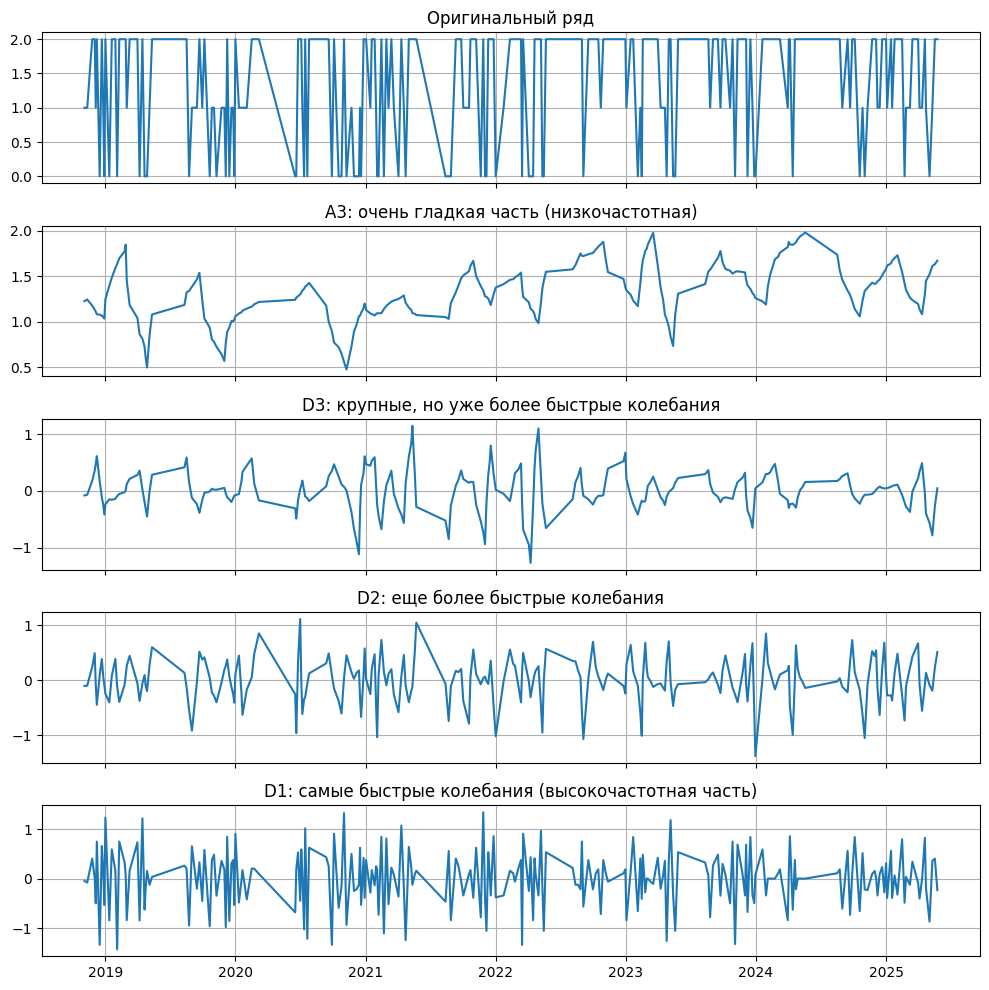

In [42]:
import pywt

# Выберем один ряд, например, series_id = 0
series_id = "Arsenal"
df_s = df_one_line[df_one_line["team"] == series_id].sort_values(by="date").copy()

# Возьмем последние N наблюдений, желательно степень двойки
N = 256
df_s = df_s.tail(N).copy()
y = df_s["match_result"].values

wavelet = "db2"  # Daubechies с двумя коэффициентами
level = 3  # 3 уровня разложения (A3, D3, D2, D1)

coeffs = pywt.wavedec(y, wavelet=wavelet, level=level)
# coeffs = [A3, D3, D2, D1]

def keep_only_one_component(coeffs, keep_idx: int):
    """
    Zeros out all components except the one at keep_idx.
    Index 0 = approximation (A_L), 1..L = details (D_L..D_1).
    """
    new_coeffs = []
    for i in range(len(coeffs)):
        if i == keep_idx:
            new_coeffs.append(coeffs[i])
        else:
            new_coeffs.append(np.zeros_like(coeffs[i]))
    return new_coeffs

# реконструкции
recon_A = pywt.waverec(keep_only_one_component(coeffs, keep_idx=0), wavelet=wavelet)
recon_D3 = pywt.waverec(keep_only_one_component(coeffs, keep_idx=1), wavelet=wavelet)
recon_D2 = pywt.waverec(keep_only_one_component(coeffs, keep_idx=2), wavelet=wavelet)
recon_D1 = pywt.waverec(keep_only_one_component(coeffs, keep_idx=3), wavelet=wavelet)

# иногда длина после реконструкции может отличаться
recon_A = recon_A[:len(y)]
recon_D3 = recon_D3[:len(y)]
recon_D2 = recon_D2[:len(y)]
recon_D1 = recon_D1[:len(y)]

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

axes[0].plot(df_s["date"], y)
axes[0].set_title("Оригинальный ряд")
axes[0].grid()

axes[1].plot(df_s["date"], recon_A)
axes[1].set_title("A3: очень гладкая часть (низкочастотная)")
axes[1].grid()

axes[2].plot(df_s["date"], recon_D3)
axes[2].set_title("D3: крупные, но уже более быстрые колебания")
axes[2].grid()

axes[3].plot(df_s["date"], recon_D2)
axes[3].set_title("D2: еще более быстрые колебания")
axes[3].grid()

axes[4].plot(df_s["date"], recon_D1)
axes[4].set_title("D1: самые быстрые колебания (высокочастотная часть)")
axes[4].grid()

plt.tight_layout()
plt.show()

In [105]:
# сохраняем, выполнять не нужно
df_one_line.to_csv('epl_one_line.csv', index=False)